# Cough Risk Detection — XGBoost Pipeline
**Bridge2AI Dataset | Binary Classification: Normal (0) vs Abnormal (1)**

### Input Files (6 CSVs)
```
train_vowels.csv      test_vowels.csv
train_coughs.csv      test_coughs.csv
train_breaths.csv     test_breaths.csv
```

### Steps
1. Install dependencies
2. Mount Drive + load all 6 CSVs
3. Combine + add task type column
4. Shuffle by participant (fix controls-then-cases ordering)
5. Encode labels + confounders
6. Re-split by participant ID
7. Train XGBoost (5-fold CV)
8. Evaluate + tune threshold
9. Save model

## Cell 1 — Install Dependencies

In [1]:
!pip install -q xgboost scikit-learn pandas numpy matplotlib

## Cell 2 — Imports

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from xgboost import XGBClassifier
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.metrics import (
    roc_auc_score,
    confusion_matrix,
    roc_curve
)

print('All imports successful')

All imports successful


## Cell 3 — Mount Google Drive

In [3]:
from google.colab import drive
drive.mount('/content/drive')

# ── UPDATE this to your folder in Drive ───────────────────────────────────
DATA_DIR = '/content/drive/MyDrive/Hackathon_Dataset/'
# ─────────────────────────────────────────────────────────────────────────

print(f'Data directory: {DATA_DIR}')

Mounted at /content/drive
Data directory: /content/drive/MyDrive/Hackathon_Dataset/


## Cell 4 — Configure Column Names
**Update these to match your actual CSV column names.**

In [4]:
# ── UPDATE THESE to match your actual column names ────────────────────────
PARTICIPANT_ID_COL = 'participant_id'
LABEL_COL          = 'disease_status'          # if already binary 0/1
DIAGNOSIS_COL      = None    # if still a string

# Confounder columns — set to None if not in your data
AGE_COL            = 'age'
SEX_COL            = 'sex_at_birth'
SMOKING_COL        = None
ALLERGY_COL        = 'seasonal_allergies'

# Healthy label strings in diagnosis colum
HEALTHY_LABELS     = None
# ─────────────────────────────────────────────────────────────────────────

print('Column config set.')

Column config set.


## Cell 5 — Load All 6 CSVs + Combine
Ignores the original train/test split entirely.
Adds a `task_type` column so the model knows which recording type each row came from.

In [5]:
files = {
    'cough':  ['train_coughs_only.csv',  'test_coughs_only.csv'],
    'breath': ['train_breaths_only.csv', 'test_breaths_only.csv'],
    'vowel':  ['train_vowels_only.csv',  'test_vowels_only.csv'],
}

dfs = []
for task_type, (train_file, test_file) in files.items():
    for fname in [train_file, test_file]:
        path = DATA_DIR + fname
        tmp  = pd.read_csv(path)
        tmp['task_type'] = task_type   # tag which recording type
        dfs.append(tmp)
        print(f'  Loaded {fname:30s} → {len(tmp):,} rows')

df = pd.concat(dfs, ignore_index=True)

print(f'\nCombined dataset: {df.shape}')
print(f'\nTask type counts:')
print(df['task_type'].value_counts())


# Load phenotypic data
pheno = pd.read_csv(DATA_DIR + 'participant_list_full.tsv', sep='\t')  # ← update filename

# Join onto main dataframe by participant_id
df = df.merge(
    pheno[['participant_id', 'age', 'sex_at_birth', 'seasonal_allergies']],
    on='participant_id',
    how='left'
)

print(f'Phenotypic data joined — shape now: {df.shape}')
print(f'Null counts for confounders:')
print(df[['age', 'sex_at_birth', 'seasonal_allergies']].isnull().sum())

  Loaded train_coughs_only.csv          → 612 rows
  Loaded test_coughs_only.csv           → 164 rows
  Loaded train_breaths_only.csv         → 1,974 rows
  Loaded test_breaths_only.csv          → 517 rows
  Loaded train_vowels_only.csv          → 937 rows
  Loaded test_vowels_only.csv           → 240 rows

Combined dataset: (4444, 246)

Task type counts:
task_type
breath    2491
vowel     1177
cough      776
Name: count, dtype: int64
Phenotypic data joined — shape now: (4612, 249)
Null counts for confounders:
age                    94
sex_at_birth           14
seasonal_allergies    212
dtype: int64


## Cell 6 — Shuffle by Participant
Fixes the controls-first / cases-last ordering.
Shuffles at the **participant level** so all sessions from one
participant stay together — preventing leakage while breaking the ordering.

In [6]:
# Get unique participants and shuffle them
unique_participants = df[PARTICIPANT_ID_COL].unique()
np.random.seed(42)
shuffled_participants = np.random.permutation(unique_participants)

# Reorder dataframe by shuffled participant order
participant_order = {pid: i for i, pid in enumerate(shuffled_participants)}
df['_sort_key']   = df[PARTICIPANT_ID_COL].map(participant_order)
df = df.sort_values('_sort_key').drop(columns='_sort_key')
df = df.reset_index(drop=True)

print(f'Shuffled {len(unique_participants):,} participants')
print(f'Total sessions after shuffle: {len(df):,}')

# Verify shuffle worked — label distribution should be ~even throughout
# Check first vs last 20% of rows
n = len(df)
first_20pct_abnormal = df.iloc[:n//5][LABEL_COL].mean() if LABEL_COL in df.columns else 'check after labeling'
last_20pct_abnormal  = df.iloc[4*n//5:][LABEL_COL].mean() if LABEL_COL in df.columns else 'check after labeling'
print(f'\nShuffle check (abnormal % in first vs last 20%):')
print(f'  First 20%: {first_20pct_abnormal}')
print(f'  Last 20%:  {last_20pct_abnormal}')
print('  (These should be similar — if one is 0.0 and other is 1.0, shuffle needed)')

Shuffled 307 participants
Total sessions after shuffle: 4,612

Shuffle check (abnormal % in first vs last 20%):
  First 20%: 0.5661605206073753
  Last 20%:  0.5633802816901409
  (These should be similar — if one is 0.0 and other is 1.0, shuffle needed)


## Cell 7 — Create Binary Label

In [7]:
if LABEL_COL in df.columns and set(df[LABEL_COL].dropna().unique()).issubset({0, 1}):
    print('Label column already binary — no mapping needed')
else:
    df[LABEL_COL] = (~df[DIAGNOSIS_COL].str.lower().isin(
        {h.lower() for h in HEALTHY_LABELS}
    )).astype(int)
    print('Diagnosis mapped to binary label')

n_normal   = (df[LABEL_COL] == 0).sum()
n_abnormal = (df[LABEL_COL] == 1).sum()
ratio      = n_normal / max(n_abnormal, 1)

print(f'\nLabel distribution (full dataset):')
print(f'  Normal   (0): {n_normal:,}')
print(f'  Abnormal (1): {n_abnormal:,}')
print(f'  Imbalance ratio (neg/pos): {ratio:.2f}')

print(f'\nLabel distribution by task type:')
print(df.groupby('task_type')[LABEL_COL].value_counts().unstack(fill_value=0))

Label column already binary — no mapping needed

Label distribution (full dataset):
  Normal   (0): 1,846
  Abnormal (1): 2,766
  Imbalance ratio (neg/pos): 0.67

Label distribution by task type:
disease_status     0     1
task_type                 
breath          1043  1545
cough            292   515
vowel            511   706


In [8]:
print(df['sex_at_birth'].value_counts())
print(df['seasonal_allergies'].value_counts())

sex_at_birth
Female    3188
Male      1410
Name: count, dtype: int64
seasonal_allergies
No     3265
Yes    1135
Name: count, dtype: int64


## Cell 8 — Encode Task Type + Confounders

In [9]:
# Sex at birth
if SEX_COL and SEX_COL in df.columns:
    df['sex_binary'] = (df[SEX_COL] == 'Male').astype(int)
    df['sex_binary'].fillna(0, inplace=True)  # fills the 14 nulls as Female
    print(f'Sex encoded: Male=1, Female=0')

# Seasonal allergies
if ALLERGY_COL and ALLERGY_COL in df.columns:
    df['has_allergies'] = (df[ALLERGY_COL] == 'Yes').astype(int)
    df['has_allergies'].fillna(0, inplace=True)  # fills 212 nulls as No
    print(f'Allergies encoded: Yes=1, No=0')

Sex encoded: Male=1, Female=0
Allergies encoded: Yes=1, No=0


In [10]:
print(df['sex_at_birth'].value_counts())
print(df['seasonal_allergies'].value_counts())

sex_at_birth
Female    3188
Male      1410
Name: count, dtype: int64
seasonal_allergies
No     3265
Yes    1135
Name: count, dtype: int64


In [12]:
# Task type — one-hot encode (cough, breath, vowel)
task_dummies = pd.get_dummies(df['task_type'], prefix='task')
df = pd.concat([df, task_dummies], axis=1)
print(f'Task type columns added: {task_dummies.columns.tolist()}')

# Age — normalize

df['age'] = pd.to_numeric(df['age'], errors='coerce')
if AGE_COL and AGE_COL in df.columns:
    age_mean = df[AGE_COL].mean()
    age_std  = df[AGE_COL].std()
    df['age_normalized'] = ((df[AGE_COL] - age_mean) / age_std).fillna(0)
    print(f'Age normalized (mean={age_mean:.1f}, std={age_std:.1f})')

# Sex — encode using exact values from your data
if SEX_COL and SEX_COL in df.columns:
    df['sex_binary'] = (df[SEX_COL] == 'Male').astype(int)
    df['sex_binary'].fillna(0, inplace=True)
    print(f'Sex encoded: Male=1, Female=0')
    print(df['sex_binary'].value_counts())

# Smoking — not in your dataset, skip
# if SMOKING_COL and SMOKING_COL in df.columns:
#     df['smoker'] = df[SMOKING_COL].fillna(0).astype(int)

# Allergies — encode using exact values from your data
if ALLERGY_COL and ALLERGY_COL in df.columns:
    df['has_allergies'] = (df[ALLERGY_COL] == 'Yes').astype(int)
    df['has_allergies'].fillna(0, inplace=True)
    print(f'Allergies encoded: Yes=1, No=0')
    print(df['has_allergies'].value_counts())

print('\nEncoding complete')

Task type columns added: ['task_breath', 'task_cough', 'task_vowel']
Age normalized (mean=52.8, std=17.4)
Sex encoded: Male=1, Female=0
sex_binary
0    3202
1    1410
Name: count, dtype: int64
Allergies encoded: Yes=1, No=0
has_allergies
0    3477
1    1135
Name: count, dtype: int64

Encoding complete


## Cell 9 — Build Feature Matrix

In [31]:
# All columns to drop before training
DROP_COLS = [
    PARTICIPANT_ID_COL,
    LABEL_COL,
    'task_type',
    AGE_COL,
    SEX_COL,
    ALLERGY_COL,
    DIAGNOSIS_COL,
    'age_normalized',
    'sex_binary',
    'has_allergies'
]

# Only drop columns that actually exist
DROP_COLS = [c for c in DROP_COLS if c in df.columns]

X      = df.drop(columns=DROP_COLS)
y      = df[LABEL_COL]
groups = df[PARTICIPANT_ID_COL]

# Keep only numeric columns
X = X.select_dtypes(include=[np.number])

# Fill any remaining nulls
null_count = X.isnull().sum().sum()
if null_count > 0:
    print(f'Filling {null_count:,} null values with column median')
    X = X.fillna(X.median())

print(f'Feature matrix shape: {X.shape}')
print(f'Features per session: {X.shape[1]}')
print(f'Total sessions:       {X.shape[0]:,}')

Feature matrix shape: (4612, 241)
Features per session: 241
Total sessions:       4,612


## Cell 10 — Re-split by Participant ID
We ignore the original train/test split entirely and re-split
properly by participant to prevent leakage.

In [32]:
unique_participants = df[PARTICIPANT_ID_COL].unique()
n_test = int(0.15 * len(unique_participants))

# Use same seed as shuffle for reproducibility
np.random.seed(42)
test_participants = np.random.choice(
    unique_participants, size=n_test, replace=False
)

test_mask  = df[PARTICIPANT_ID_COL].isin(test_participants)
train_mask = ~test_mask

X_train = X[train_mask];      y_train = y[train_mask]
X_test  = X[test_mask];       y_test  = y[test_mask]
groups_train = groups[train_mask]

print(f'Split by participant to prevent leakage:')
print(f'  Total participants:  {len(unique_participants):,}')
print(f'  Test participants:   {n_test:,}')
print(f'  Train sessions:      {len(X_train):,}')
print(f'  Test sessions:       {len(X_test):,}')
print(f'  Train abnormal %:    {y_train.mean()*100:.1f}%')
print(f'  Test abnormal %:     {y_test.mean()*100:.1f}%')
print()

# Check task type balance in train vs test
train_tasks = df[train_mask]['task_type'].value_counts(normalize=True)
test_tasks  = df[test_mask]['task_type'].value_counts(normalize=True)
print('Task type distribution (train vs test):')
print(pd.DataFrame({'train': train_tasks, 'test': test_tasks}).round(2))

Split by participant to prevent leakage:
  Total participants:  307
  Test participants:   46
  Train sessions:      3,944
  Test sessions:       668
  Train abnormal %:    60.2%
  Test abnormal %:     58.7%

Task type distribution (train vs test):
           train  test
task_type             
breath      0.56  0.56
vowel       0.26  0.26
cough       0.18  0.17


## Cell 11 — Train XGBoost (5-Fold CV)

In [33]:
from sklearn.metrics import accuracy_score, f1_score, recall_score, precision_score

pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print(f'Class imbalance weight: {pos_weight:.2f}')

cv        = StratifiedGroupKFold(n_splits=5)
oof_preds = np.zeros(len(X_train))
fold_aucs = []

# Track all metrics per fold
fold_metrics = []

xgb_params = dict(
    n_estimators          = 500,
    max_depth             = 6,
    learning_rate         = 0.05,
    subsample             = 0.8,
    colsample_bytree      = 0.8,
    scale_pos_weight      = pos_weight,
    eval_metric           = 'auc',
    early_stopping_rounds = 20,
    random_state          = 42,
    verbosity             = 0
)

for fold, (tr_idx, val_idx) in enumerate(
    cv.split(X_train, y_train, groups_train)
):
    model = XGBClassifier(**xgb_params)
    model.fit(
        X_train.iloc[tr_idx], y_train.iloc[tr_idx],
        eval_set=[(X_train.iloc[val_idx], y_train.iloc[val_idx])],
        verbose=False
    )
    fold_probs = model.predict_proba(X_train.iloc[val_idx])[:, 1]
    fold_preds = (fold_probs > 0.35).astype(int)
    oof_preds[val_idx] = fold_probs

    # Compute all metrics
    tn, fp, fn, tp = confusion_matrix(
        y_train.iloc[val_idx], fold_preds, labels=[0,1]
    ).ravel()

    metrics = {
        'fold':        fold + 1,
        'auc':         roc_auc_score(y_train.iloc[val_idx], fold_probs),
        'accuracy':    accuracy_score(y_train.iloc[val_idx], fold_preds),
        'sensitivity': tp / max(tp + fn, 1),
        'specificity': tn / max(tn + fp, 1),
        'f1':          f1_score(y_train.iloc[val_idx], fold_preds),
        'ppv':         precision_score(y_train.iloc[val_idx], fold_preds),
    }
    fold_metrics.append(metrics)

    print(f'  Fold {fold+1}  AUC={metrics["auc"]:.3f}  '
          f'Acc={metrics["accuracy"]:.3f}  '
          f'Sens={metrics["sensitivity"]:.3f}  '
          f'Spec={metrics["specificity"]:.3f}  '
          f'F1={metrics["f1"]:.3f}')

# Summary table
metrics_df = pd.DataFrame(fold_metrics).set_index('fold')
print(f'\nCross Validation Summary (threshold=0.35):')
print(metrics_df.round(3))
print(f'\nMean:')
print(metrics_df.mean().round(3))
print(f'\nStd:')
print(metrics_df.std().round(3))

mean_cv_auc = roc_auc_score(y_train, oof_preds)
print(f'\nOverall OOF AUC: {mean_cv_auc:.3f}')

Class imbalance weight: 0.66
  Fold 1  AUC=0.846  Acc=0.760  Sens=0.876  Spec=0.587  F1=0.815
  Fold 2  AUC=0.814  Acc=0.734  Sens=0.894  Spec=0.494  F1=0.802
  Fold 3  AUC=0.770  Acc=0.729  Sens=0.899  Spec=0.473  F1=0.800
  Fold 4  AUC=0.717  Acc=0.657  Sens=0.751  Spec=0.514  F1=0.725
  Fold 5  AUC=0.752  Acc=0.690  Sens=0.850  Spec=0.447  F1=0.768

Cross Validation Summary (threshold=0.35):
        auc  accuracy  sensitivity  specificity     f1    ppv
fold                                                         
1     0.846     0.760        0.876        0.587  0.815  0.761
2     0.814     0.734        0.894        0.494  0.802  0.727
3     0.770     0.729        0.899        0.473  0.800  0.721
4     0.717     0.657        0.751        0.514  0.725  0.702
5     0.752     0.690        0.850        0.447  0.768  0.700

Mean:
auc            0.780
accuracy       0.714
sensitivity    0.854
specificity    0.503
f1             0.782
ppv            0.722
dtype: float64

Std:
auc           

## Cell 12 — Retrain on Full Training Set

In [34]:
print('Retraining on full training set...')

# Remove early stopping for final retrain — no val set needed
final_params = {k: v for k, v in xgb_params.items()
                if k != 'early_stopping_rounds'}

final_model = XGBClassifier(**final_params)
final_model.fit(X_train, y_train)
print('Done.')

Retraining on full training set...
Done.


## Cell 13 — Evaluate on Test Set

In [35]:
from sklearn.metrics import accuracy_score, f1_score, precision_score

test_probs = final_model.predict_proba(X_test)[:, 1]
test_preds = (test_probs > 0.35).astype(int)
test_auc   = roc_auc_score(y_test, test_probs)

tn, fp, fn, tp = confusion_matrix(y_test, test_preds, labels=[0,1]).ravel()

print(f'Test Set Results (threshold=0.35):')
print(f'  AUC:         {test_auc:.3f}')
print(f'  Accuracy:    {accuracy_score(y_test, test_preds):.3f}')
print(f'  Sensitivity: {tp / max(tp + fn, 1):.3f}')
print(f'  Specificity: {tn / max(tn + fp, 1):.3f}')
print(f'  F1 Score:    {f1_score(y_test, test_preds):.3f}')
print(f'  PPV:         {precision_score(y_test, test_preds):.3f}')
print(f'  TP: {tp}  FP: {fp}  TN: {tn}  FN: {fn}')

print(f'\nThreshold Tuning:')
print(f'{"Threshold":>10} {"AUC":>6} {"Accuracy":>10} {"Sensitivity":>12} {"Specificity":>12} {"F1":>6} {"PPV":>8}')
print('-' * 68)

best_threshold = 0.35
for t in np.arange(0.2, 0.8, 0.05):
    preds = (test_probs > t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, preds, labels=[0,1]).ravel()
    sensitivity  = tp / max(tp + fn, 1)
    specificity  = tn / max(tn + fp, 1)
    accuracy     = accuracy_score(y_test, preds)
    f1           = f1_score(y_test, preds)
    ppv          = precision_score(y_test, preds)
    print(f'{t:>10.2f} {test_auc:>6.3f} {accuracy:>10.3f} '
          f'{sensitivity:>12.3f} {specificity:>12.3f} '
          f'{f1:>6.3f} {ppv:>8.3f}')

Test Set Results (threshold=0.35):
  AUC:         0.794
  Accuracy:    0.735
  Sensitivity: 0.893
  Specificity: 0.511
  F1 Score:    0.798
  PPV:         0.722
  TP: 350  FP: 135  TN: 141  FN: 42

Threshold Tuning:
 Threshold    AUC   Accuracy  Sensitivity  Specificity     F1      PPV
--------------------------------------------------------------------
      0.20  0.794      0.714        0.944        0.388  0.795    0.686
      0.25  0.794      0.725        0.926        0.438  0.798    0.701
      0.30  0.794      0.731        0.911        0.475  0.799    0.711
      0.35  0.794      0.735        0.893        0.511  0.798    0.722
      0.40  0.794      0.735        0.870        0.543  0.794    0.730
      0.45  0.794      0.722        0.839        0.554  0.780    0.728
      0.50  0.794      0.723        0.819        0.587  0.776    0.738
      0.55  0.794      0.723        0.796        0.620  0.771    0.748
      0.60  0.794      0.728        0.783        0.649  0.771    0.760
     

## Cell 14 — Evaluate by Task Type
Check whether model performs equally well across cough, breath, and vowel recordings.

In [36]:
test_df = df[test_mask].copy()
test_df['prob']      = test_probs
test_df['predicted'] = (test_probs > best_threshold).astype(int)

print('Performance by task type:')
print(f'{"Task":>10} {"AUC":>8} {"Sensitivity":>12} {"Specificity":>12} {"N":>6}')
print('-' * 52)

for task in ['cough', 'breath', 'vowel']:
    mask = test_df['task_type'] == task
    if mask.sum() == 0:
        continue
    t_probs  = test_df.loc[mask, 'prob']
    t_labels = test_df.loc[mask, LABEL_COL]
    t_preds  = test_df.loc[mask, 'predicted']

    auc = roc_auc_score(t_labels, t_probs) if t_labels.nunique() > 1 else float('nan')
    tn, fp, fn, tp = confusion_matrix(t_labels, t_preds, labels=[0,1]).ravel()
    sens = tp / max(tp + fn, 1)
    spec = tn / max(tn + fp, 1)
    print(f'{task:>10} {auc:>8.3f} {sens:>12.2f} {spec:>12.2f} {mask.sum():>6}')

Performance by task type:
      Task      AUC  Sensitivity  Specificity      N
----------------------------------------------------
     cough    0.835         0.97         0.39    116
    breath    0.795         0.85         0.56    376
     vowel    0.777         0.92         0.47    176


## Cell 15 — ROC Curve

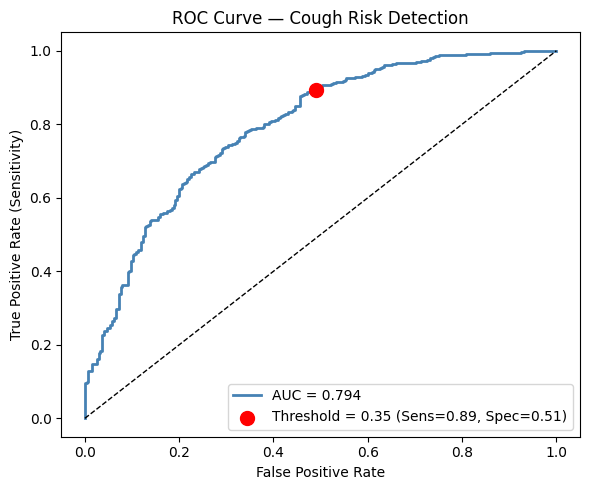

Saved → roc_curve.png


In [37]:
fpr, tpr, thresholds = roc_curve(y_test, test_probs)

# Find the point on the curve closest to threshold 0.35
threshold_idx = np.argmin(np.abs(thresholds - 0.35))

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, color='steelblue', lw=2,
         label=f'AUC = {test_auc:.3f}')
plt.plot([0, 1], [0, 1], 'k--', lw=1)

# Plot the chosen threshold point
plt.scatter(
    fpr[threshold_idx],
    tpr[threshold_idx],
    color='red', zorder=5, s=100,
    label=f'Threshold = 0.35 '
          f'(Sens={tpr[threshold_idx]:.2f}, '
          f'Spec={1-fpr[threshold_idx]:.2f})'
)

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate (Sensitivity)')
plt.title('ROC Curve — Cough Risk Detection')
plt.legend()
plt.tight_layout()
plt.savefig('roc_curve.png', dpi=150)
plt.show()
print('Saved → roc_curve.png')

## Cell 16 — Feature Importance

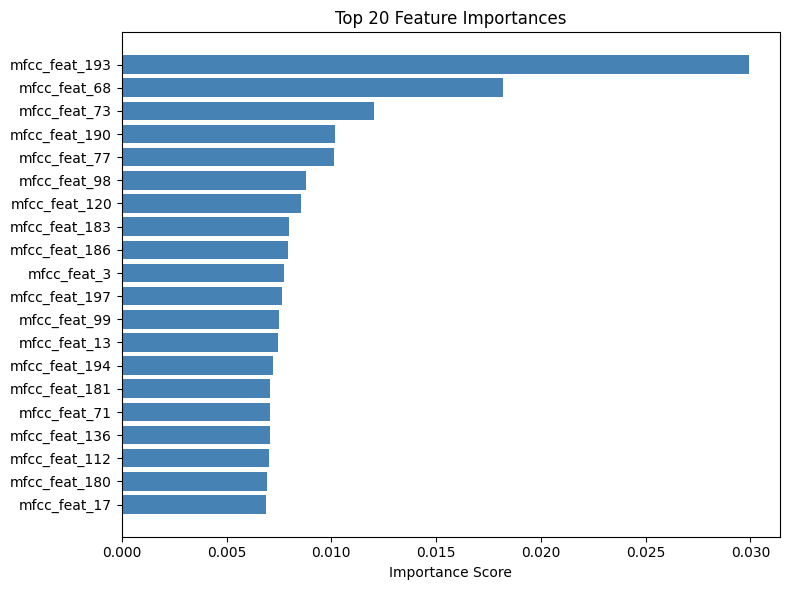

Saved → feature_importance.png

Confounder + task type importance ranks:


In [38]:
importance_df = pd.DataFrame({
    'feature':    X_train.columns,
    'importance': final_model.feature_importances_
}).sort_values('importance', ascending=True).tail(20)

plt.figure(figsize=(8, 6))
plt.barh(importance_df['feature'], importance_df['importance'],
         color='steelblue')
plt.xlabel('Importance Score')
plt.title('Top 20 Feature Importances')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150)
plt.show()
print('Saved → feature_importance.png')

# Check where confounders + task type rank
full_importance = pd.DataFrame({
    'feature':    X_train.columns,
    'importance': final_model.feature_importances_
}).sort_values('importance', ascending=False).reset_index(drop=True)

check_cols = ['age_normalized', 'sex_binary', 'smoker',
              'has_allergies', 'task_cough', 'task_breath', 'task_vowel']

print('\nConfounder + task type importance ranks:')
for col in check_cols:
    if col in full_importance['feature'].values:
        rank = full_importance[full_importance['feature'] == col].index[0] + 1
        imp  = full_importance[full_importance['feature'] == col]['importance'].values[0]
        print(f'  {col:20s} rank #{rank:3d}   importance: {imp:.4f}')

## Cell 17 — Save Model

In [40]:
MODEL_PATH = 'cough_risk_model.json'
final_model.save_model(MODEL_PATH)
print(f'Model saved → {MODEL_PATH}')

try:
    drive_path = DATA_DIR + 'cough_risk_model.json'
    final_model.save_model(drive_path)
    print(f'Model also saved to Drive → {drive_path}')
except:
    print('(Drive save skipped)')

# Save feature column order — needed for inference
feature_cols = X_train.columns.tolist()
pd.Series(feature_cols).to_csv('feature_columns.csv', index=False)
print(f'Feature column order saved → feature_columns.csv')

print(f'\n── Final Summary ──────────────────────────')
print(f'  CV AUC:                {mean_cv_auc:.3f}')
print(f'  Test AUC:              {test_auc:.3f}')
print(f'  Recommended threshold: {best_threshold}')
print(f'  Total sessions:        {len(df):,}')
print(f'  Features used:         {X_train.shape[1]}')

Model saved → cough_risk_model.json
Model also saved to Drive → /content/drive/MyDrive/Hackathon_Dataset/cough_risk_model.json
Feature column order saved → feature_columns.csv

── Final Summary ──────────────────────────
  CV AUC:                0.774
  Test AUC:              0.794
  Recommended threshold: 0.35
  Total sessions:        4,612
  Features used:         241


In [41]:
MODEL_PATH = 'cough_risk_model.json'
final_model.save_model(MODEL_PATH)
print(f'Model saved → {MODEL_PATH}')

try:
    drive_path = DATA_DIR + 'cough_risk_model.json'
    final_model.save_model(drive_path)
    print(f'Model also saved to Drive → {drive_path}')
except:
    print('(Drive save skipped)')

# Save feature columns locally
feature_cols = X_train.columns.tolist()
pd.Series(feature_cols).to_csv('feature_columns.csv', index=False)
print(f'Feature column order saved → feature_columns.csv')

# Also save feature columns to Drive  ← add this
try:
    pd.Series(feature_cols).to_csv(DATA_DIR + 'feature_columns.csv', index=False)
    print(f'Feature columns also saved to Drive → {DATA_DIR}feature_columns.csv')
except:
    print('(Drive feature columns save skipped)')

print(f'\n── Final Summary ──────────────────────────')
print(f'  CV AUC:                {mean_cv_auc:.3f}')
print(f'  Test AUC:              {test_auc:.3f}')
print(f'  Recommended threshold: {best_threshold}')
print(f'  Total sessions:        {len(df):,}')
print(f'  Features used:         {X_train.shape[1]}')

Model saved → cough_risk_model.json
Model also saved to Drive → /content/drive/MyDrive/Hackathon_Dataset/cough_risk_model.json
Feature column order saved → feature_columns.csv
Feature columns also saved to Drive → /content/drive/MyDrive/Hackathon_Dataset/feature_columns.csv

── Final Summary ──────────────────────────
  CV AUC:                0.774
  Test AUC:              0.794
  Recommended threshold: 0.35
  Total sessions:        4,612
  Features used:         241


In [42]:
print(df['n_frames'].describe())

count    4612.000000
mean      807.398959
std       449.556436
min         9.000000
25%       480.000000
50%       693.000000
75%      1088.500000
max      5266.000000
Name: n_frames, dtype: float64


In [44]:
mfcc_cols = [c for c in X_train.columns if 'mfcc' in c.lower()]
print(f'Total MFCC columns: {len(mfcc_cols)}')
print(f'Divided by 60 coefficients = {len(mfcc_cols) / 60:.0f} frames')


Total MFCC columns: 240
Divided by 60 coefficients = 4 frames


## Cell 18 — Inference Function (for app)

In [ ]:
def predict_risk(
    feature_row: dict,
    model_path: str   = 'cough_risk_model.json',
    columns_path: str = 'feature_columns.csv',
    threshold: float  = None
) -> dict:
    """
    Score a single new session from the app.

    Args:
        feature_row:  dict of feature_name -> value
        model_path:   path to saved .json model
        columns_path: path to saved feature column order
        threshold:    decision threshold (defaults to best_threshold)

    Returns:
        dict with risk_score (0-1), at_risk (bool), threshold used
    """
    if threshold is None:
        threshold = best_threshold

    # Load model + expected column order
    m = XGBClassifier()
    m.load_model(model_path)
    cols = pd.read_csv(columns_path).iloc[:, 0].tolist()

    # Align columns — fill any missing with 0
    X_new = pd.DataFrame([feature_row]).reindex(columns=cols, fill_value=0)
    score = float(m.predict_proba(X_new)[:, 1][0])

    return {
        'risk_score': round(score, 4),
        'at_risk':    score > threshold,
        'threshold':  threshold
    }

# Example:
# result = predict_risk({'feature_1': 0.5, 'task_cough': 1, ...})
# → {'risk_score': 0.73, 'at_risk': True, 'threshold': 0.35}

print('Inference function ready.')